**Docker image**: `ml4t`

# Label Engineering Methods

**Chapter 7: Defining the Learning Task**
**Section Reference**: 7.2 - Label Engineering

## Purpose

This notebook demonstrates **all major labeling methods** for ML-based trading
strategies, with practical examples on real ETF data. It serves as the canonical
reference for choosing and configuring labels across all modeling chapters.

## Learning Objectives

1. Understand fixed-horizon vs path-dependent labels
2. Compare time-series vs **cross-sectional** percentile approaches
3. Implement triple-barrier with fixed and ATR-based thresholds
4. Visualize barrier mechanics with price path examples
5. Understand anchor alignment (close-to-close vs next-open)

## Prerequisites

- `01_data_quality_diagnostics` - establishes the ETF coverage assumptions used here.
- Familiarity with leakage-aware splitting (Chapter 6 §6.3) and forward-return semantics.
- Polars DataFrame manipulation; basic statistics (t-statistics, percentiles).

## Data Contract

- **Input**: Real ETF OHLCV from data loaders (SPY for single-asset, full universe for cross-sectional)
- **Output**: Example labels for teaching (use `compute_labels()` for production)

In [1]:
"""Label Methods - fixed-horizon, cross-sectional, and event-driven labeling for supervised learning."""

from __future__ import annotations

import warnings
from collections.abc import Sequence
from datetime import datetime

import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
from IPython.display import display
from ml4t.engineer.config.labeling import LabelingConfig
from ml4t.engineer.labeling import (
    atr_triple_barrier_labels,
    calculate_label_uniqueness,
    compute_bet_size,
    fixed_time_horizon_labels,
    meta_labels,
    rolling_percentile_binary_labels,
    sequential_bootstrap,
    trend_scanning_labels,
    triple_barrier_labels,
)
from plotly.subplots import make_subplots
from scipy import stats as sp_stats

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS  # importing also registers the ML4T Plotly template

warnings.filterwarnings("ignore")

/home/stefan/ml4t/code/.venv/lib/python3.14/site-packages/ml4t/engineer/features/ml/__init__.py:9: UserWarning: Feature 'cyclical_encode': lookback=0 but has period/window parameter. Consider using lookback='period' or specifying the actual lookback.
  from ml4t.engineer.features.ml.cyclical_encode import *  # noqa: F403


In [2]:
SEED = 42
START_DATE = "2015-01-01"
END_DATE = "2024-12-31"

In [3]:
set_global_seeds(SEED)

## Helper Functions

Robust label column discovery to avoid brittle hardcoded column names.

In [4]:
def first_col_matching_any(df: pl.DataFrame, needles: Sequence[str]) -> str:
    """
    Return the first column whose name contains any of the substrings in needles.
    Raises ValueError if no match is found.
    """
    lowered = [(c, c.lower()) for c in df.columns]
    for c, c_low in lowered:
        for n in needles:
            if n.lower() in c_low:
                return c
    raise ValueError(f"No column found matching: {needles}")

## 1. Load Sample Data

We use the ETF universe for demonstrations. SPY serves as the single-asset
example; the full universe enables cross-sectional analysis.

In [5]:
# Load ETF universe
etf = load_etfs()

# Filter date range
date_filter = (pl.col("timestamp") >= datetime.strptime(START_DATE, "%Y-%m-%d")) & (
    pl.col("timestamp") <= datetime.strptime(END_DATE, "%Y-%m-%d")
)

etf_filtered = (
    etf.filter(date_filter)
    .sort(["symbol", "timestamp"])
    .with_columns(pl.col("timestamp").cast(pl.Datetime("us")))
)

# SPY for single-asset demos
spy = etf_filtered.filter(pl.col("symbol") == "SPY").sort("timestamp")

print(f"ETF universe: {etf_filtered['symbol'].n_unique()} symbols")
print(f"SPY data: {len(spy):,} days from {spy['timestamp'].min()} to {spy['timestamp'].max()}")
spy.head()

ETF universe: 100 symbols
SPY data: 2,516 days from 2015-01-02 00:00:00 to 2024-12-31 00:00:00


timestamp,open,high,low,close,volume,symbol
datetime[μs],f64,f64,f64,f64,f64,str
2015-01-02 00:00:00,170.911744,171.325815,169.089824,170.125,1.214659e8,"""SPY"""
2015-01-05 00:00:00,169.081586,169.247212,166.746235,167.052643,1.696326e8,"""SPY"""
2015-01-06 00:00:00,167.358997,167.88073,164.684105,165.479126,2.091514e8,"""SPY"""
2015-01-07 00:00:00,166.804154,167.88074,166.356963,167.541199,1.253467e8,"""SPY"""
2015-01-08 00:00:00,168.949035,170.729546,168.932482,170.514221,1.472178e8,"""SPY"""


## 2. Fixed Time Horizon Labels

The simplest approach: compute forward returns over a fixed window.
This is the workhorse of factor-based ML strategies.

### Methods

| Method | Description | Use Case |
|--------|-------------|----------|
| `"returns"` | Raw percentage return | Regression targets |
| `"binary"` | +1 if return > 0, else -1 | Classification |
| `"log_returns"` | Log return | Regression with better properties |

In [6]:
# 21 trading days is a common "one month" convention in daily data
horizon = 21

labels_returns = fixed_time_horizon_labels(
    spy,
    horizon=horizon,
    method="returns",
    price_col="close",
)

# Discover the produced label column robustly
fh_label_col = first_col_matching_any(labels_returns, [f"{horizon}", "label_return", "label"])
print(f"Fixed Horizon Labels (horizon={horizon}):")
print(f"  Column added: {fh_label_col}")
labels_returns.select(["timestamp", "close", fh_label_col]).head(10)

Fixed Horizon Labels (horizon=21):
  Column added: label_return_21p


timestamp,close,label_return_21p
datetime[μs],f64,f64
2015-01-02 00:00:00,170.125,-0.002872
2015-01-05 00:00:00,167.052643,0.0116
2015-01-06 00:00:00,165.479126,0.031528
2015-01-07 00:00:00,167.541199,0.016015
2015-01-08 00:00:00,170.514221,-0.006168
2015-01-09 00:00:00,169.147797,0.012534
2015-01-12 00:00:00,167.822754,0.02112
2015-01-13 00:00:00,167.350708,0.033848
2015-01-14 00:00:00,166.340408,0.044409


### Return vs binary comparison

Both methods use the same forward window but produce different target types:
continuous returns for regression, binary direction for classification.

In [7]:
labels_binary = fixed_time_horizon_labels(
    spy,
    horizon=horizon,
    method="binary",
    price_col="close",
)

binary_label_col = first_col_matching_any(labels_binary, ["direction", "label"])

print("Return distribution:")
display(labels_returns[fh_label_col].describe())
print("Binary label distribution:")
display(labels_binary.group_by(binary_label_col).len().sort(binary_label_col))

Return distribution:


statistic,value
str,f64
"""count""",2495.0
"""null_count""",21.0
"""mean""",0.011676
"""std""",0.044669
"""min""",-0.327513
"""25%""",-0.007745
"""50%""",0.016858
"""75%""",0.036822
"""max""",0.25185


Binary label distribution:


label_direction_21p,len
i8,u32
null,21
-1,783
1,1712


## 3. Anchor Alignment Demo

**Critical concept**: The anchor point determines when returns are measured.
Different anchors produce different labels even with the same horizon.

- **Close-to-close**: Decision at close, measure return from close to H-day close
- **Next-open-to-open**: Decision at close, execute at next open, measure from there

This is one of the most common sources of subtle lookahead bias.

In [8]:
# Compute both anchor alignments
spy_anchors = spy.with_columns(
    [
        # Close-to-close: standard approach
        (pl.col("close").shift(-horizon) / pl.col("close") - 1).alias("ret_close_to_close"),
        # Next-open-to-open: decision at close(t), execute at open(t+1), exit at open(t+horizon+1)
        # Holding for `horizon` trading days means exit is horizon+1 bars from decision
        (pl.col("open").shift(-(horizon + 1)) / pl.col("open").shift(-1) - 1).alias(
            "ret_next_open_to_open"
        ),
    ]
).drop_nulls()

# Compute the difference
spy_anchors = spy_anchors.with_columns(
    [(pl.col("ret_close_to_close") - pl.col("ret_next_open_to_open")).alias("anchor_diff")]
)

print(f"Mean close-to-close return:    {spy_anchors['ret_close_to_close'].mean():.4f}")
print(f"Mean next-open-to-open return: {spy_anchors['ret_next_open_to_open'].mean():.4f}")
print(f"Mean difference:               {spy_anchors['anchor_diff'].mean():.4f}")
print(f"Std difference:                {spy_anchors['anchor_diff'].std():.4f}")

Mean close-to-close return:    0.0117
Mean next-open-to-open return: 0.0117
Mean difference:               0.0000
Std difference:                0.0102


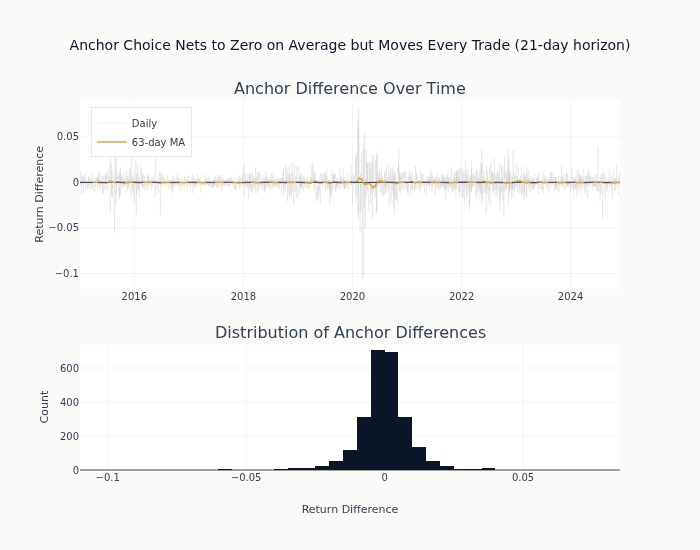

In [9]:
# Visualize the difference over time
fig = make_subplots(
    rows=2,
    cols=1,
    subplot_titles=[
        "Anchor Difference Over Time",
        "Distribution of Anchor Differences",
    ],
    row_heights=[0.6, 0.4],
    vertical_spacing=0.15,
)

# Raw daily differences (light) with 63-day rolling mean overlay
fig.add_trace(
    go.Scatter(
        x=spy_anchors["timestamp"].to_list(),
        y=spy_anchors["anchor_diff"].to_numpy(),
        mode="lines",
        name="Daily",
        line=dict(width=0.3, color="rgba(100,100,100,0.3)"),
    ),
    row=1,
    col=1,
)

# Rolling mean to show structural pattern
rolling_mean = spy_anchors["anchor_diff"].rolling_mean(63)
fig.add_trace(
    go.Scatter(
        x=spy_anchors["timestamp"].to_list(),
        y=rolling_mean.to_numpy(),
        mode="lines",
        name="63-day MA",
        line=dict(width=1.5, color=COLORS["amber"]),
    ),
    row=1,
    col=1,
)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], line_width=0.8, row=1, col=1)

# Histogram of differences
fig.add_trace(
    go.Histogram(
        x=spy_anchors["anchor_diff"].to_numpy(),
        nbinsx=50,
        name="Distribution",
        showlegend=False,
        marker_color=COLORS["blue"],
    ),
    row=2,
    col=1,
)

fig.update_yaxes(title_text="Return Difference", row=1, col=1)
fig.update_xaxes(title_text="Return Difference", row=2, col=1)
fig.update_yaxes(title_text="Count", row=2, col=1)
fig.update_layout(
    height=550,
    title_text=f"Anchor Choice Nets to Zero on Average but Moves Every Trade ({horizon}-day horizon)",
    font=dict(size=12),
    showlegend=True,
    legend=dict(x=0.02, y=0.98),
)
fig.show()

In [10]:
# Example timestamps showing anchor shift
spy_anchors.select(
    ["timestamp", "close", "open", "ret_close_to_close", "ret_next_open_to_open", "anchor_diff"]
).head(10)

timestamp,close,open,ret_close_to_close,ret_next_open_to_open,anchor_diff
datetime[μs],f64,f64,f64,f64,f64
2015-01-02 00:00:00,170.125,170.911744,-0.002872,-0.001225,-0.001648
2015-01-05 00:00:00,167.052643,169.081586,0.0116,0.013707,-0.002107
2015-01-06 00:00:00,165.479126,167.358997,0.031528,0.025519,0.006009
2015-01-07 00:00:00,167.541199,166.804154,0.016015,0.003726,0.01229
2015-01-08 00:00:00,170.514221,168.949035,-0.006168,-0.002519,-0.003649
2015-01-09 00:00:00,169.147797,170.928295,0.012534,0.010763,0.001771
2015-01-12 00:00:00,167.822754,169.28029,0.02112,0.01847,0.002651
2015-01-13 00:00:00,167.350708,169.04011,0.033848,0.047183,-0.013335
2015-01-14 00:00:00,166.340408,165.338352,0.044409,0.038536,0.005874


**Key Insight**: The anchor difference is noisy at the trade level (standard
deviation ~100bps for SPY), even though it averages close to zero. This means
individual label assignments can differ substantially between anchors, affecting
model training. For end-of-day signals executed at next open, labels should use
next-open anchoring to match the actual execution price.

## 4. Time-Series Percentile Labels

Labels are relative to recent history for a **single instrument**,
making them adaptive to volatility regimes.

In [11]:
# Binary percentile: Is return in top 25%?
labels_ts_pct = rolling_percentile_binary_labels(
    spy,
    horizon=horizon,
    percentile=75,  # Top 25%
    direction="long",
    lookback_window=252,  # 1 year rolling window
    price_col="close",
)

# Find the label column robustly
ts_pct_label_col = first_col_matching_any(labels_ts_pct, ["label"])
print("Time-Series Percentile Labels (p75):")
print(f"  Column added: {ts_pct_label_col}")

# Show distribution
print("Label Distribution:")
display(labels_ts_pct.group_by(ts_pct_label_col).len().sort(ts_pct_label_col))

Time-Series Percentile Labels (p75):
  Column added: label_long_p75_h21
Label Distribution:


label_long_p75_h21,len
i8,u32
null,46
0,1853
1,617


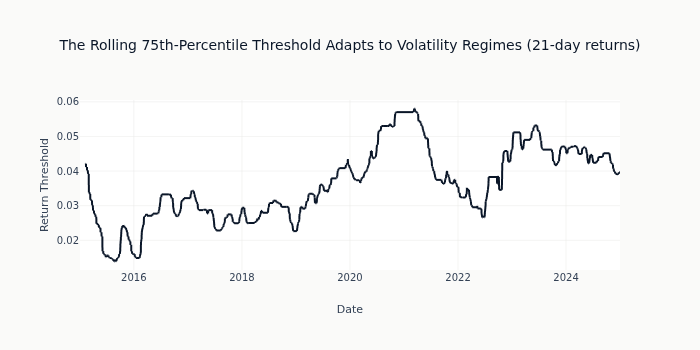

In [12]:
# Visualize threshold adaptation
threshold_col = [c for c in labels_ts_pct.columns if "threshold" in c.lower()]
if threshold_col:
    fig = px.line(
        labels_ts_pct.to_pandas(),
        x="timestamp",
        y=threshold_col[0],
        title=f"The Rolling 75th-Percentile Threshold Adapts to Volatility Regimes ({horizon}-day returns)",
    )
    fig.update_layout(height=350, xaxis_title="Date", yaxis_title="Return Threshold")
    fig.show()

## 5. Cross-Sectional Percentile Labels

**The most natural use of percentile labels**: rank assets within the universe
at each decision time, then label top/bottom quantiles.

This is the standard approach for equity and ETF rotation strategies.

In [13]:
# Compute forward returns and cross-sectional rank for the entire ETF universe
etf_with_fwd = etf_filtered.with_columns(
    [(pl.col("close").shift(-horizon) / pl.col("close") - 1).over("symbol").alias("fwd_return")]
).drop_nulls(subset=["fwd_return"])

etf_cs = etf_with_fwd.with_columns(
    [
        pl.col("fwd_return").rank(method="average").over("timestamp").alias("rank"),
        pl.col("fwd_return").count().over("timestamp").alias("n_symbols"),
    ]
).with_columns(
    [
        # Percentile rank: 0-100 scale (guard against single-symbol dates)
        pl.when(pl.col("n_symbols") > 1)
        .then((pl.col("rank") - 1) / (pl.col("n_symbols") - 1) * 100)
        .otherwise(None)
        .alias("pct_rank")
    ]
)

print(f"Cross-sectional ranking: {len(etf_cs):,} asset-date observations")

Cross-sectional ranking: 248,436 asset-date observations


Cross-sectional percentile labels rank assets at each decision time $t$.
This is inherently point-in-time: the ranking at $t$ uses only returns
realized at $t$, so no future information leaks into label construction.

In [14]:
# Assign labels: top quintile = +1, bottom quintile = -1, else 0
quintile_threshold = 20  # Top/bottom 20%
etf_cs = etf_cs.with_columns(
    [
        pl.when(pl.col("pct_rank") >= (100 - quintile_threshold))
        .then(pl.lit(1))
        .when(pl.col("pct_rank") <= quintile_threshold)
        .then(pl.lit(-1))
        .otherwise(pl.lit(0))
        .alias("cs_label")
    ]
)

print(f"Cross-Sectional Labels ({horizon}d horizon, {quintile_threshold}th percentile cutoffs):")
print(f"  Total observations: {len(etf_cs):,}")
display(etf_cs.group_by("cs_label").len().sort("cs_label"))

Cross-Sectional Labels (21d horizon, 20th percentile cutoffs):
  Total observations: 248,436


cs_label,len
i32,u32
-1,49900
0,148636
1,49900


In [15]:
# Verify stable class proportions over time
# Note: Counts vary if universe size changes; proportions are stable by construction.
label_by_date = (
    etf_cs.group_by(["timestamp", "cs_label"])
    .len()
    .pivot(on="cs_label", index="timestamp", values="len")
    .sort("timestamp")
)

# Convert counts to proportions
count_cols = [c for c in label_by_date.columns if c != "timestamp"]
if count_cols:
    label_by_date = label_by_date.with_columns([pl.col(c).fill_null(0) for c in count_cols])
    label_by_date = label_by_date.with_columns(
        pl.sum_horizontal([pl.col(c) for c in count_cols]).alias("_total")
    )
    label_by_date = label_by_date.with_columns(
        [
            pl.when(pl.col("_total") > 0)
            .then(pl.col(c) / pl.col("_total"))
            .otherwise(None)
            .alias(c)
            for c in count_cols
        ]
    )

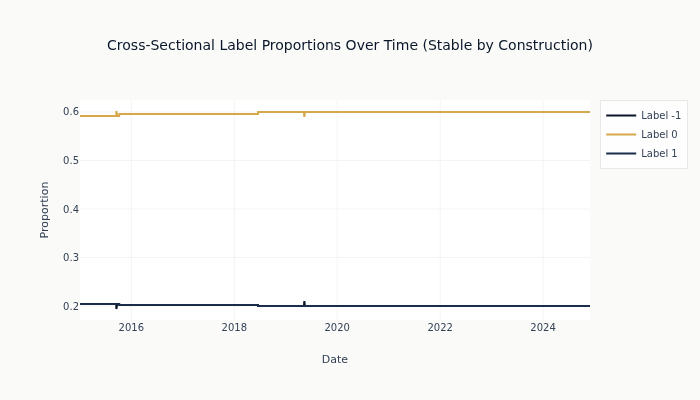

In [16]:
# Show class proportions over time
fig = go.Figure()
for label in [-1, 0, 1]:
    col_name = str(label)
    if col_name in label_by_date.columns:
        fig.add_trace(
            go.Scatter(
                x=label_by_date["timestamp"].to_list(),
                y=label_by_date[col_name].to_numpy(),
                mode="lines",
                name=f"Label {label}",
            )
        )

fig.update_layout(
    height=400,
    title="Cross-Sectional Label Proportions Over Time (Stable by Construction)",
    xaxis_title="Date",
    yaxis_title="Proportion",
)
fig.show()

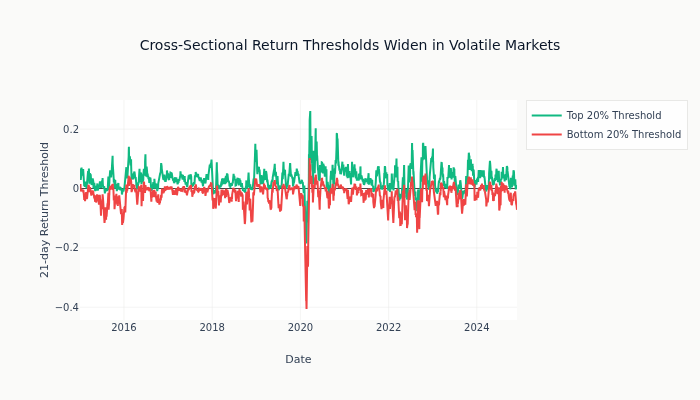

In [17]:
# Show cross-sectional threshold values over time
cs_thresholds = (
    etf_with_fwd.group_by("timestamp")
    .agg(
        [
            pl.col("fwd_return").quantile(quintile_threshold / 100).alias("bottom_threshold"),
            pl.col("fwd_return").quantile(1 - quintile_threshold / 100).alias("top_threshold"),
        ]
    )
    .sort("timestamp")
)

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=cs_thresholds["timestamp"].to_list(),
        y=cs_thresholds["top_threshold"].to_numpy(),
        mode="lines",
        name="Top 20% Threshold",
        line=dict(color=COLORS["positive"]),
    )
)
fig.add_trace(
    go.Scatter(
        x=cs_thresholds["timestamp"].to_list(),
        y=cs_thresholds["bottom_threshold"].to_numpy(),
        mode="lines",
        name="Bottom 20% Threshold",
        line=dict(color=COLORS["negative"]),
    )
)
fig.update_layout(
    height=400,
    title="Cross-Sectional Return Thresholds Widen in Volatile Markets",
    xaxis_title="Date",
    yaxis_title=f"{horizon}-day Return Threshold",
)
fig.show()

**Key Insight**: Cross-sectional percentile labels maintain stable class distributions
by construction, but the absolute return thresholds vary with market conditions.
In high-volatility periods, larger absolute returns are needed to qualify as "top quintile".

## 6. Triple-Barrier Labels

Path-dependent labeling that captures realistic trade outcomes:
- **Upper barrier**: Take profit hit → +1
- **Lower barrier**: Stop loss hit → -1
- **Time barrier**: Neither hit → label based on final return

This method is from De Prado's *Advances in Financial Machine Learning*.

In [18]:
# Fixed percentage barriers: 2% take profit, 1% stop loss
config = LabelingConfig.triple_barrier(
    upper_barrier=0.02,  # 2% take profit
    lower_barrier=0.01,  # 1% stop loss
    max_holding_period=20,  # 20 days max
    side=1,  # Long positions only
)

labels_tb = triple_barrier_labels(
    spy,
    config=config,
    price_col="close",
    timestamp_col="timestamp",
    calculate_uniqueness=True,  # Compute sample weights
)

print("Triple-Barrier Labels (Fixed %):")
print("Label Distribution:")
display(labels_tb.group_by("label").len().sort("label"))

print("Barrier Hit Distribution:")
display(labels_tb.group_by("barrier_hit").len().sort("barrier_hit"))

Triple-Barrier Labels (Fixed %):
Label Distribution:


label,len
i32,u32
-1,1254
0,158
1,1104


Barrier Hit Distribution:


barrier_hit,len
str,u32
"""lower""",1254
"""time""",158
"""upper""",1104


### 6.1 Triple-Barrier Path Visualization

**Understanding triple-barrier requires seeing the price paths**.
Below we plot several example trades showing how barriers are hit.

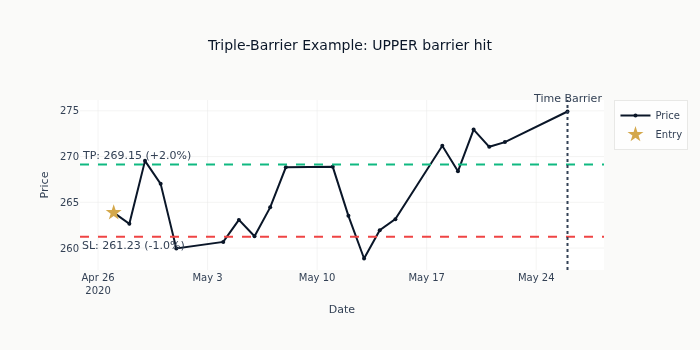

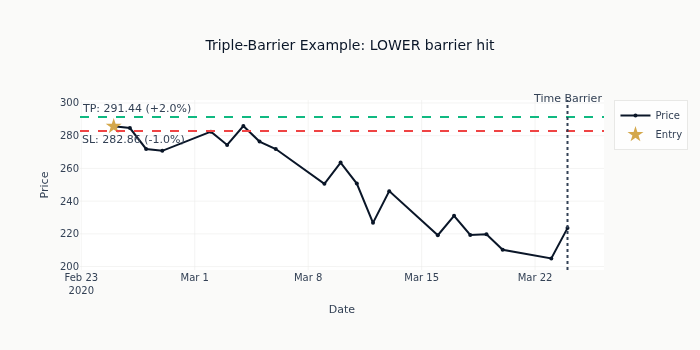

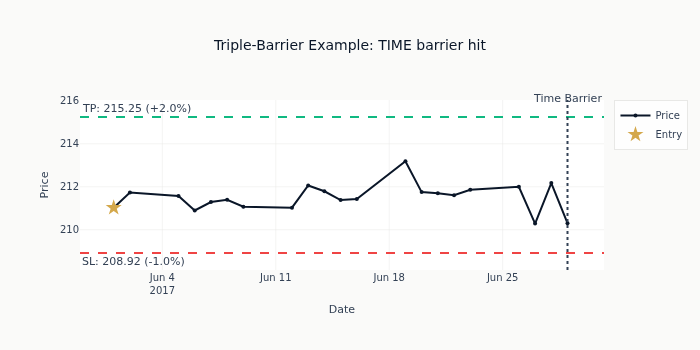

In [19]:
# Find examples of each barrier hit type
tb_with_price = labels_tb.join(
    spy.select(["timestamp", "close"]), on="timestamp", how="left"
).with_row_index("row_idx")


def plot_triple_barrier_example(
    df: pl.DataFrame, entry_idx: int, config: LabelingConfig, title: str
) -> go.Figure:
    """Plot a single triple-barrier trade example with barriers overlaid."""
    # Get entry point
    entry_row = df.row(entry_idx, named=True)
    entry_price = entry_row["close"]
    entry_time = entry_row["timestamp"]

    # Calculate barrier levels
    upper_level = entry_price * (1 + config.upper_barrier)
    lower_level = entry_price * (1 - config.lower_barrier)

    # Get the forward price path
    forward_rows = df.filter(pl.col("timestamp") >= entry_time).head(config.max_holding_period + 1)

    fig = go.Figure()

    # Price path
    fig.add_trace(
        go.Scatter(
            x=forward_rows["timestamp"].to_list(),
            y=forward_rows["close"].to_numpy(),
            mode="lines+markers",
            name="Price",
            line=dict(color=COLORS["blue"], width=2),
            marker=dict(size=4),
        )
    )

    # Entry point
    fig.add_trace(
        go.Scatter(
            x=[entry_time],
            y=[entry_price],
            mode="markers",
            name="Entry",
            marker=dict(color=COLORS["amber"], size=12, symbol="star"),
        )
    )

    # Upper barrier (horizontal line) - label on the left to clear the time-barrier text
    fig.add_hline(
        y=upper_level,
        line_dash="dash",
        line_color=COLORS["positive"],
        annotation_text=f"TP: {upper_level:.2f} (+{config.upper_barrier:.1%})",
        annotation_position="top left",
    )

    # Lower barrier (horizontal line)
    fig.add_hline(
        y=lower_level,
        line_dash="dash",
        line_color=COLORS["negative"],
        annotation_text=f"SL: {lower_level:.2f} (-{config.lower_barrier:.1%})",
        annotation_position="bottom left",
    )

    # Time barrier (vertical line at end)
    # Note: Use add_shape instead of add_vline with annotation to avoid Plotly datetime bug
    time_barrier = forward_rows["timestamp"].to_list()[-1] if len(forward_rows) > 0 else entry_time
    fig.add_shape(
        type="line",
        x0=time_barrier,
        x1=time_barrier,
        y0=0,
        y1=1,
        yref="paper",
        line=dict(color=COLORS["neutral"], dash="dot"),
    )
    fig.add_annotation(
        x=time_barrier,
        y=1,
        yref="paper",
        text="Time Barrier",
        showarrow=False,
        yshift=10,
    )

    fig.update_layout(
        height=350,
        title=title,
        xaxis_title="Date",
        yaxis_title="Price",
        showlegend=True,
    )
    return fig


# Find examples of each barrier type
if "barrier_hit" in labels_tb.columns:
    # Get indices for different barrier hits
    examples = []

    for barrier_type in ["upper", "lower", "time"]:
        matches = tb_with_price.filter(
            (pl.col("barrier_hit") == barrier_type) & (pl.col("close").is_not_null())
        )
        if len(matches) > 10:
            # Pick an example from the middle of the dataset
            idx = len(matches) // 2
            row_idx = matches["row_idx"][idx]
            examples.append((barrier_type, row_idx))

    # Plot examples
    for barrier_type, idx in examples[:3]:  # Limit to 3 examples
        if idx < len(tb_with_price):
            fig = plot_triple_barrier_example(
                tb_with_price,
                idx,
                config,
                f"Triple-Barrier Example: {barrier_type.upper()} barrier hit",
            )
            fig.show()

### 6.2 ATR-Based Barriers

Volatility-adjusted barriers adapt to market conditions:
- Low volatility → Tighter barriers (capture smaller moves)
- High volatility → Wider barriers (avoid whipsaws)

In [20]:
# Compute ATR and convert to percentage-of-price barriers
atr_period = 14
atr_tp_multiple = 1.0  # 1x ATR take profit
atr_sl_multiple = 0.5  # 0.5x ATR stop loss (tighter asymmetric)

spy_atr = (
    spy.with_columns(
        pl.max_horizontal(
            pl.col("high") - pl.col("low"),
            (pl.col("high") - pl.col("close").shift(1)).abs(),
            (pl.col("low") - pl.col("close").shift(1)).abs(),
        ).alias("true_range")
    )
    .with_columns(pl.col("true_range").rolling_mean(atr_period).alias("atr_dollar"))
    .with_columns(
        # Express barriers as fraction of entry price so they match the return-based engine
        (atr_tp_multiple * pl.col("atr_dollar") / pl.col("close")).alias("upper_barrier_pct"),
        (atr_sl_multiple * pl.col("atr_dollar") / pl.col("close")).alias("lower_barrier_pct"),
    )
    .drop_nulls()
)

In [21]:
# Use triple_barrier_labels with dynamic per-row percentage barriers
atr_config = LabelingConfig.triple_barrier(
    upper_barrier="upper_barrier_pct",
    lower_barrier="lower_barrier_pct",
    max_holding_period=20,
    side=1,
)
labels_atr = triple_barrier_labels(
    spy_atr,
    config=atr_config,
    price_col="close",
    timestamp_col="timestamp",
)

print("ATR Triple-Barrier Labels:")
print(f"  ATR period: {atr_period}, TP: {atr_tp_multiple}x ATR, SL: {atr_sl_multiple}x ATR")
print("Label Distribution:")
display(labels_atr.group_by("label").len().sort("label"))

if "barrier_hit" in labels_atr.columns:
    print("Barrier Hit Distribution:")
    display(labels_atr.group_by("barrier_hit").len().sort("barrier_hit"))

print("ATR as % of Close:")
display(spy_atr["upper_barrier_pct"].describe())

ATR Triple-Barrier Labels:
  ATR period: 14, TP: 1.0x ATR, SL: 0.5x ATR
Label Distribution:


label,len
i32,u32
-1,1273
0,4
1,1226


Barrier Hit Distribution:


barrier_hit,len
str,u32
"""lower""",1273
"""time""",4
"""upper""",1226


ATR as % of Close:


statistic,value
str,f64
"""count""",2503.0
"""null_count""",0.0
"""mean""",0.012523
"""std""",0.007779
"""min""",0.003371
"""25%""",0.007721
"""50%""",0.010216
"""75%""",0.015278
"""max""",0.083803


### 6.3 Sample Weights from Uniqueness

Overlapping labels create mechanical dependence: high-concurrency periods
dominate training loss. Weighting by uniqueness prevents these periods
from overwhelming the model. De Prado introduces **uniqueness-based
sample weights** where more unique samples (less overlap) get higher weights.

Sample Weight Statistics:


statistic,value
str,f64
"""count""",2516.0
"""null_count""",0.0
"""mean""",1.0
"""std""",1.051682
"""min""",0.0
"""25%""",0.402811
"""50%""",0.693517
"""75%""",1.237279
"""max""",15.163374


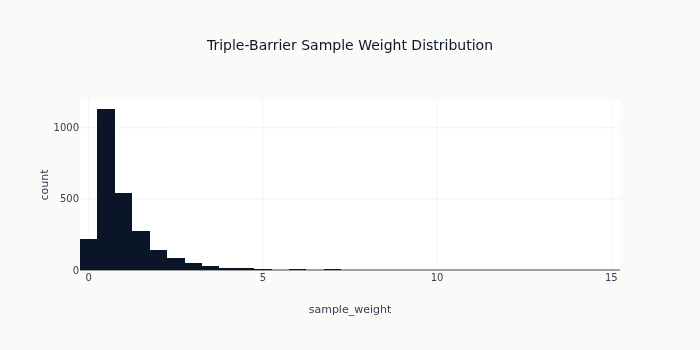

In [22]:
if "sample_weight" in labels_tb.columns:
    print("Sample Weight Statistics:")
    display(labels_tb["sample_weight"].describe())

    # Visualize weight distribution
    fig = px.histogram(
        labels_tb.filter(pl.col("sample_weight").is_not_null()).to_pandas(),
        x="sample_weight",
        nbins=50,
        title="Triple-Barrier Sample Weight Distribution",
    )
    fig.update_layout(height=350)
    fig.show()

### 6.4 Rich Triple-Barrier Output

Unlike simple forward-return labels, triple-barrier output includes the **full
trade outcome**. This is critical for MFE/MAE analysis (NB04) and position
sizing (Ch20).

In [23]:
# Display all output columns from triple_barrier_labels
output_cols = [
    c for c in labels_tb.columns if c.startswith("label") or c in ("barrier_hit", "sample_weight")
]
print("Triple-Barrier Output Columns:")
for col in output_cols:
    dtype = labels_tb[col].dtype
    print(f"  {col:<20} {str(dtype):<12} - {labels_tb[col].drop_nulls().head(1).to_list()}")

Triple-Barrier Output Columns:
  label                Int32        - [-1]
  label_time           Datetime(time_unit='us', time_zone=None) - [datetime.datetime(2015, 1, 5, 0, 0)]
  label_price          Float64      - [167.05264282226562]
  label_return         Float64      - [-0.018059410302626745]
  label_bars           Int64        - [1]
  label_duration       Duration(time_unit='us') - [datetime.timedelta(days=3)]
  barrier_hit          String       - ['lower']
  label_uniqueness     Float64      - [0.75]
  sample_weight        Float64      - [3.753870380490634]


In [24]:
# Summary table: mean return and median holding period by barrier type
barrier_summary = (
    labels_tb.filter(pl.col("barrier_hit").is_not_null())
    .group_by("barrier_hit")
    .agg(
        count=pl.len(),
        mean_return=pl.col("label_return").mean(),
        median_bars=pl.col("label_bars").median(),
    )
    .sort("barrier_hit")
)
print("Trade Outcomes by Barrier Type:")
display(barrier_summary)

Trade Outcomes by Barrier Type:


barrier_hit,count,mean_return,median_bars
str,u32,f64,f64
"""lower""",1254,-0.017281,3.0
"""time""",158,0.00736,20.0
"""upper""",1104,0.024827,6.0


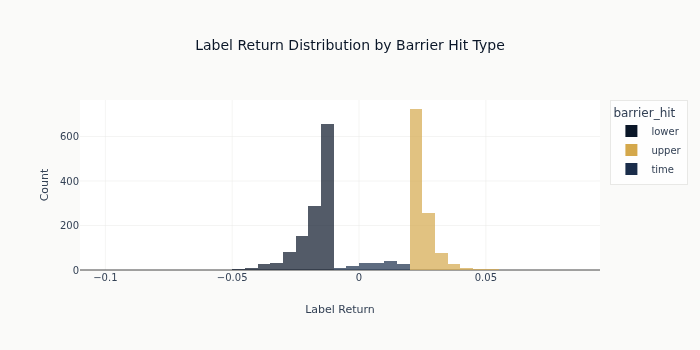

In [25]:
# Return distribution colored by barrier hit type
fig = px.histogram(
    labels_tb.filter(pl.col("label_return").is_not_null()).to_pandas(),
    x="label_return",
    color="barrier_hit",
    nbins=50,
    barmode="overlay",
    opacity=0.7,
    title="Label Return Distribution by Barrier Hit Type",
)
fig.update_layout(height=350, xaxis_title="Label Return", yaxis_title="Count")
fig.show()

### 6.5 Sequential Bootstrap

Overlapping labels create sample dependence. The **sequential bootstrap**
(De Prado, AFML Ch4) generates bootstrap indices that respect label
uniqueness - favoring samples with less concurrent overlap.

In [26]:
# Extract label lifetimes as index ranges for the uniqueness calculation
tb_valid = labels_tb.filter(pl.col("label_bars").is_not_null()).with_row_index("idx")

starts = tb_valid["idx"].to_numpy().astype(np.int64)
ends = (starts + tb_valid["label_bars"].to_numpy().astype(np.int64)).clip(max=len(tb_valid) - 1)

# Compute uniqueness from indices
uniqueness = calculate_label_uniqueness(starts, ends, n_bars=len(tb_valid))

print(f"Label Uniqueness: mean={uniqueness.mean():.3f}, std={uniqueness.std():.3f}")
print(f"  Range: [{uniqueness.min():.3f}, {uniqueness.max():.3f}]")

Label Uniqueness: mean=0.166, std=0.104
  Range: [0.048, 0.750]


In [27]:
# Sequential bootstrap vs naive random sampling
n_draws = min(len(starts), 500)
seq_indices = sequential_bootstrap(starts, ends, n_draws=n_draws, random_state=SEED)
naive_indices = np.random.default_rng(SEED).choice(len(starts), size=n_draws, replace=True)

# Compare uniqueness of selected samples
seq_uniqueness = uniqueness[seq_indices]
naive_uniqueness = uniqueness[naive_indices]

print("Bootstrap Comparison:")
print(f"  Sequential mean uniqueness: {seq_uniqueness.mean():.3f}")
print(f"  Naive mean uniqueness:      {naive_uniqueness.mean():.3f}")
print(f"  Improvement:                {(seq_uniqueness.mean() / naive_uniqueness.mean() - 1):.1%}")

Bootstrap Comparison:
  Sequential mean uniqueness: 0.185
  Naive mean uniqueness:      0.163
  Improvement:                13.7%


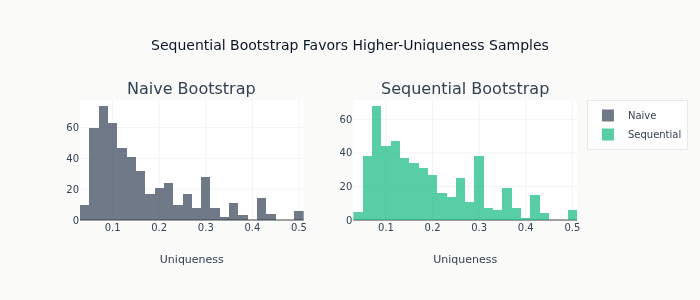

In [28]:
# Visualize the difference
fig = make_subplots(rows=1, cols=2, subplot_titles=["Naive Bootstrap", "Sequential Bootstrap"])

fig.add_trace(
    go.Histogram(
        x=naive_uniqueness, nbinsx=30, name="Naive", marker_color=COLORS["neutral"], opacity=0.7
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Histogram(
        x=seq_uniqueness, nbinsx=30, name="Sequential", marker_color=COLORS["positive"], opacity=0.7
    ),
    row=1,
    col=2,
)
fig.update_xaxes(title_text="Uniqueness", row=1, col=1)
fig.update_xaxes(title_text="Uniqueness", row=1, col=2)
fig.update_layout(height=300, title_text="Sequential Bootstrap Favors Higher-Uniqueness Samples")
fig.show()

Sequential bootstrap produces training sets where each sample contributes
more independent information. This reduces effective sample size but
improves model generalization on overlapping label data.

### 6.6 Effective Sample Size

The section text defines $N_{\text{eff}} = \sum_{t,a} w_{t,a}$ and notes that
for fixed-horizon labels sampled at every bar, $N_{\text{eff}} \approx N / H$.

That is an approximation. Below we *measure* $N_{\text{eff}}$ by computing each
label's average uniqueness $w_{t,a}$ directly - per symbol, since concurrency
accumulates along the time axis, not across the cross-section - and compare it
to the $N/H$ shortcut. We report both the single-asset (SPY) and the full-panel
figures, because they answer different questions: how many independent
observations does *one* series carry, and how many does the *panel* carry.

In [29]:
# Measure effective sample size for fixed-horizon labels on the ETF universe.
#
# Uniqueness depends only on the label index geometry (start, end, n_bars), not on
# prices: label i is alive over bars [i, i+H], and w_i averages 1/c(u) over that span.
# Concurrency is a per-symbol quantity - two different ETFs' labels do not overlap
# each other in the sense the uniqueness weight measures - so we sum per symbol.
N_nominal = len(etf_with_fwd)
n_symbols = etf_with_fwd["symbol"].n_unique()

# For fixed-horizon labels sampled at every bar, uniqueness ≈ 1/H so N_eff ≈ N/H.
# This is what the section text quotes; we keep it to compare against the measurement.
N_eff_approx = N_nominal / horizon


def measure_n_eff(n_labels: int, h: int) -> tuple[float, float]:
    """Return (mean average-uniqueness, N_eff) for n_labels contiguous H-bar labels."""
    starts = np.arange(n_labels)
    w = calculate_label_uniqueness(starts, starts + h, n_bars=n_labels + h)
    return float(w.mean()), float(w.sum())


# Single asset: SPY. This is the number quoted for a one-series study.
spy_labels = etf_with_fwd.filter(pl.col("symbol") == "SPY").height
spy_mean_u, spy_n_eff = measure_n_eff(spy_labels, horizon)

# Full panel: sum N_eff across symbols (each symbol has its own length).
panel_n_eff = 0.0
for (_sym,), grp in etf_with_fwd.group_by("symbol"):
    if grp.height > horizon:
        panel_n_eff += measure_n_eff(grp.height, horizon)[1]

panel_mean_u = panel_n_eff / N_nominal
se_inflation = np.sqrt(N_nominal / panel_n_eff)

print(f"Fixed-horizon ETF labels (H={horizon}):")
print(f"  Symbols:              {n_symbols}")
print(f"  Nominal N (panel):    {N_nominal:,}")
print()
print(f"  SPY: labels           {spy_labels:,}")
print(f"       avg uniqueness   {spy_mean_u:.4f}   (≈ 1/(H+1) = {1 / (horizon + 1):.4f})")
print(f"       N_eff (measured) {spy_n_eff:,.0f}")
print()
print(f"  Panel: avg uniqueness {panel_mean_u:.4f}")
print(f"         N_eff measured {panel_n_eff:,.0f}")
print(
    f"         N_eff ≈ N/H    {N_eff_approx:,.0f}   (the shortcut, off by "
    f"{100 * (N_eff_approx / panel_n_eff - 1):.1f}%)"
)
print(
    f"  SE inflation:         √(N/N_eff) = {se_inflation:.2f}× "
    f"(confidence intervals based on N are this much too narrow)"
)
print()
print("  Note: a label spans H+1 bars inclusive of both endpoints, so maximal")
print(f"  overlap gives w = 1/(H+1) = {1 / (horizon + 1):.4f}, not 1/H = {1 / horizon:.4f}.")
print("  That is why the measured N_eff sits slightly below the N/H shortcut.")

Fixed-horizon ETF labels (H=21):
  Symbols:              100
  Nominal N (panel):    248,436

  SPY: labels           2,495
       avg uniqueness   0.0458   (≈ 1/(H+1) = 0.0455)
       N_eff (measured) 114

  Panel: avg uniqueness 0.0458
         N_eff measured 11,388
         N_eff ≈ N/H    11,830   (the shortcut, off by 3.9%)
  SE inflation:         √(N/N_eff) = 4.67× (confidence intervals based on N are this much too narrow)

  Note: a label spans H+1 bars inclusive of both endpoints, so maximal
  overlap gives w = 1/(H+1) = 0.0455, not 1/H = 0.0476.
  That is why the measured N_eff sits slightly below the N/H shortcut.


## 7. Trend Scanning Labels

De Prado's adaptive approach that identifies trends using t-statistics.
The method scans forward with varying windows and selects the one
with the highest statistical significance.

In [30]:
labels_trend = trend_scanning_labels(
    spy,
    min_window=5,  # Minimum 5 days
    max_window=20,  # Maximum 20 days
    step=1,  # Check every window size
    price_col="close",
)

print("Trend Scanning Labels:")
print("Label Distribution:")
display(labels_trend.group_by("label").len().sort("label"))

if "t_value" in labels_trend.columns:
    print("T-Value Statistics:")
    display(labels_trend["t_value"].describe())

Trend Scanning Labels:
Label Distribution:


label,len
i8,u32
null,5
-1,835
1,1676


T-Value Statistics:


statistic,value
str,f64
"""count""",2516.0
"""null_count""",0.0
"""mean""",NaN
"""std""",NaN
"""min""",-24.614798
"""25%""",-3.869797
"""50%""",4.877316
"""75%""",8.357836
"""max""",40.957685


### 7.1 Selection Bias in Trend Scanning

Trend scanning picks the horizon with the strongest t-statistic for each
observation. This maximization introduces **selection bias**: the reported
t-statistics are systematically inflated. The Bonferroni correction raises
the critical value to account for the number of horizons tested, requiring
each t-statistic to clear a higher bar for significance.

In [31]:
# Distribution of selected horizons
if "optimal_window" in labels_trend.columns:
    horizon_col = "optimal_window"
elif "best_window" in labels_trend.columns:
    horizon_col = "best_window"
else:
    horizon_col = None

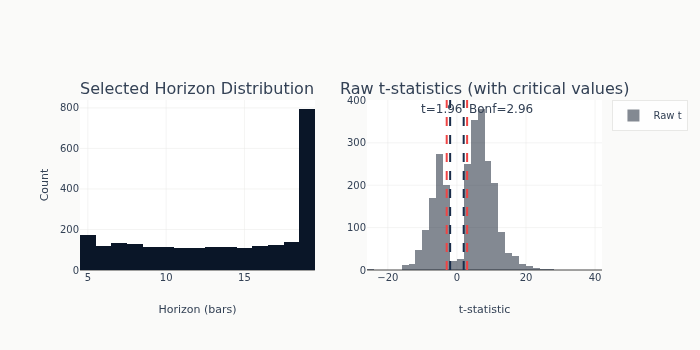

In [32]:
if horizon_col is not None:
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=["Selected Horizon Distribution", "Raw t-statistics (with critical values)"],
    )

    # (a) Histogram of selected horizons
    selected_horizons = labels_trend[horizon_col].drop_nulls().cast(pl.Int32, strict=False)
    fig.add_trace(
        go.Histogram(
            x=selected_horizons.to_numpy(),
            nbinsx=16,
            name="Selected horizon",
            marker_color=COLORS["blue"],
            showlegend=False,
        ),
        row=1,
        col=1,
    )

    # (b) Raw t-statistics vs Bonferroni-adjusted critical value
    if "t_value" in labels_trend.columns:
        n_candidates = 20 - 5 + 1  # max_window - min_window + 1
        raw_t = labels_trend["t_value"].drop_nulls()

        # Bonferroni: raise the critical value by dividing alpha by n_candidates
        alpha = 0.05
        bonferroni_crit = sp_stats.norm.ppf(1 - alpha / (2 * n_candidates))

        fig.add_trace(
            go.Histogram(
                x=raw_t.to_numpy(),
                nbinsx=50,
                name="Raw t",
                marker_color=COLORS["blue"],
                opacity=0.5,
            ),
            row=1,
            col=2,
        )

        # Mark both critical values - stagger the labels (left vs right) so they don't overlap
        fig.add_vline(
            x=1.96,
            line_dash="dash",
            line_color=COLORS["slate"],
            annotation_text="t=1.96",
            annotation_position="top left",
            row=1,
            col=2,
        )
        fig.add_vline(x=-1.96, line_dash="dash", line_color=COLORS["slate"], row=1, col=2)
        fig.add_vline(
            x=bonferroni_crit,
            line_dash="dash",
            line_color=COLORS["negative"],
            annotation_text=f"Bonf={bonferroni_crit:.2f}",
            annotation_position="top right",
            row=1,
            col=2,
        )
        fig.add_vline(
            x=-bonferroni_crit, line_dash="dash", line_color=COLORS["negative"], row=1, col=2
        )

        # Significance counts
        raw_significant = (raw_t.abs() > 1.96).sum()
        corrected_significant = (raw_t.abs() > bonferroni_crit).sum()

    fig.update_xaxes(title_text="Horizon (bars)", row=1, col=1)
    fig.update_xaxes(title_text="t-statistic", row=1, col=2)
    fig.update_yaxes(title_text="Count", row=1, col=1)
    fig.update_layout(height=350, font=dict(size=12))
    fig.show()

The Bonferroni correction is conservative but illustrates the magnitude of
the selection effect. After correction, many trends that appeared "significant"
under the uncorrected test lose significance - confirming the text's warning
that uncorrected trend scanning t-statistics should not be taken at face value.

In [33]:
if horizon_col is not None and "t_value" in labels_trend.columns:
    sign_change_frac = 1 - corrected_significant / max(raw_significant, 1)
    print(f"Candidate horizons tested: {n_candidates}")
    print(f"Bonferroni critical value: {bonferroni_crit:.2f} (vs 1.96 uncorrected)")
    print(
        f"Significant at 5% (raw):        {raw_significant:,} / {len(raw_t):,} ({raw_significant / len(raw_t):.1%})"
    )
    print(
        f"Significant at 5% (Bonferroni): {corrected_significant:,} / {len(raw_t):,} ({corrected_significant / len(raw_t):.1%})"
    )
    print(f"Fraction losing significance:    {sign_change_frac:.1%}")

Candidate horizons tested: 16
Bonferroni critical value: 2.96 (vs 1.96 uncorrected)
Significant at 5% (raw):        2,475 / 2,516 (98.4%)
Significant at 5% (Bonferroni): 2,320 / 2,516 (92.2%)
Fraction losing significance:    6.3%


## 7.5 Meta-Labeling Concept

**Meta-labeling** separates the signal from the sizing decision:

1. A primary model generates directional signals (+1 long, -1 short)
2. Triple-barrier labels determine whether each signal was profitable
3. A secondary (meta) model learns *when to act* and *how much to bet*

This decomposes the problem: the primary model handles *direction*,
the meta-model handles *confidence*. The cells below illustrate the
construction on SPY; the case studies in this book do not adopt
meta-labeling (each case study trains a single model on one label
horizon and sizes positions through an allocator), but the pattern
transfers directly to any directional model already in place.

In [34]:
# Simple primary signal: buy when 20-day momentum is positive
spy_meta = spy.with_columns(
    signal=pl.when(pl.col("close") > pl.col("close").shift(20)).then(1).otherwise(-1),
    fwd_return=(pl.col("close").shift(-horizon) / pl.col("close") - 1),
).drop_nulls()

# Create meta-labels: was the signal profitable?
spy_meta = meta_labels(spy_meta, signal_col="signal", return_col="fwd_return")

print("Meta-Label Distribution:")
display(spy_meta.group_by("meta_label").len().sort("meta_label"))

Meta-Label Distribution:


meta_label,len
i32,u32
0,1096
1,1399


In [35]:
# Bet sizing: convert meta-model probability to position size
# Here we use the meta_label directly as a proxy for probability
spy_meta = spy_meta.with_columns(
    # Simulate a meta-model probability (in practice, this comes from a trained classifier)
    pseudo_prob=pl.col("meta_label").cast(pl.Float64) * 0.3 + 0.5,
).with_columns(
    bet_size=compute_bet_size("pseudo_prob", method="sigmoid", scale=5.0),
)

print("Bet Size Statistics (sigmoid method):")
display(spy_meta["bet_size"].describe())

Bet Size Statistics (sigmoid method):


statistic,value
str,f64
"""count""",2495.0
"""null_count""",0.0
"""mean""",0.356142
"""std""",0.315287
"""min""",0.0
"""25%""",0.0
"""50%""",0.635149
"""75%""",0.635149
"""max""",0.635149


**Key Insight**: Meta-labeling turns a classification problem (direction)
into a probability calibration problem (confidence). This enables
Kelly-criterion-style position sizing from ML predictions.

## 8. Label Diagnostics

The function below provides a reusable diagnostic template. Run it on any
label column to check distribution stability and class balance-the two
properties that determine whether a label is learnable.


Fixed Horizon (21d) Continuous Label Diagnostics


statistic,value
str,f64
"""count""",2495.0
"""null_count""",0.0
"""mean""",0.011676
"""std""",0.044669
"""min""",-0.327513
"""25%""",-0.007745
"""50%""",0.016858
"""75%""",0.036822
"""max""",0.25185


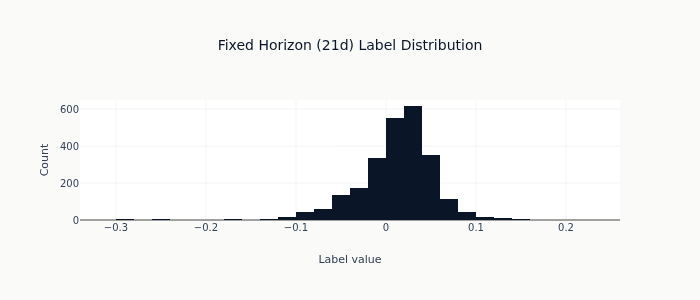

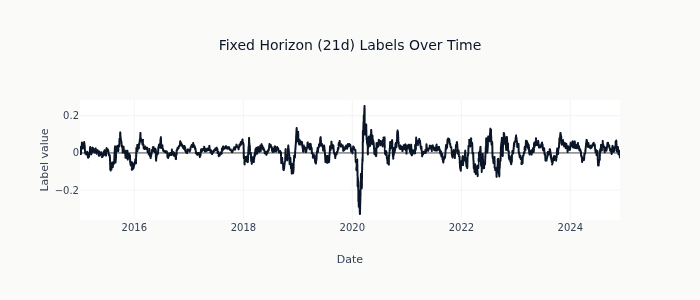

In [36]:
def label_diagnostics(
    df: pl.DataFrame,
    label_col: str,
    timestamp_col: str = "timestamp",
    title_prefix: str = "",
) -> None:
    """
    Generate diagnostic plots for any label column.

    Works with both continuous (returns) and discrete (classification) labels.
    """
    labels = df[label_col].drop_nulls()
    n_unique = labels.n_unique()
    is_discrete = n_unique <= 10  # Heuristic: discrete if few unique values

    if is_discrete:
        # Discrete label diagnostics
        print(f"\n{'=' * 60}")
        print(f"{title_prefix} Discrete Label Diagnostics")
        print(f"{'=' * 60}")
        print(f"Unique values: {labels.unique().sort().to_list()}")

        # Exclude nulls from value counts
        df_non_null = df.drop_nulls(subset=[label_col])
        print("Value Counts:")
        display(df_non_null.group_by(label_col).len().sort(label_col))

        # Bar chart of label distribution
        fig = px.bar(
            df_non_null.group_by(label_col).len().sort(label_col).to_pandas(),
            x=label_col,
            y="len",
            title=f"{title_prefix} Label Distribution",
        )
        fig.update_layout(height=300)
        fig.show()

        # Class balance over time
        if timestamp_col in df.columns:
            by_date = (
                df.group_by([timestamp_col, label_col])
                .len()
                .pivot(on=label_col, index=timestamp_col, values="len")
                .sort(timestamp_col)
            )
            # Compute class proportions (robust to missing classes on a date)
            count_cols = [c for c in by_date.columns if c != timestamp_col]
            if count_cols:
                by_date = by_date.with_columns([pl.col(c).fill_null(0) for c in count_cols])
                by_date = by_date.with_columns(
                    pl.sum_horizontal([pl.col(c) for c in count_cols]).alias("_total")
                )
                by_date = by_date.with_columns(
                    [
                        pl.when(pl.col("_total") > 0)
                        .then(pl.col(c) / pl.col("_total"))
                        .otherwise(None)
                        .alias(f"{c}_pct")
                        for c in count_cols
                    ]
                )

            # Plot proportions
            fig = go.Figure()
            for col in by_date.columns:
                if col.endswith("_pct"):
                    fig.add_trace(
                        go.Scatter(
                            x=by_date[timestamp_col].to_list(),
                            y=by_date[col].to_numpy(),
                            mode="lines",
                            name=col.replace("_pct", ""),
                        )
                    )
            fig.update_layout(
                height=300,
                title=f"{title_prefix} Class Proportions Over Time",
                yaxis_title="Proportion",
            )
            fig.show()
    else:
        # Continuous label diagnostics
        print(f"\n{'=' * 60}")
        print(f"{title_prefix} Continuous Label Diagnostics")
        print(f"{'=' * 60}")
        display(labels.describe())

        # Histogram
        fig = px.histogram(
            x=labels.to_numpy(),
            nbins=50,
            title=f"{title_prefix} Label Distribution",
        )
        fig.update_layout(height=300, xaxis_title="Label value", yaxis_title="Count")
        fig.show()

        # Time series if available
        if timestamp_col in df.columns:
            fig = px.line(
                df.select([timestamp_col, label_col]).drop_nulls().to_pandas(),
                x=timestamp_col,
                y=label_col,
                title=f"{title_prefix} Labels Over Time",
            )
            fig.update_layout(height=300, xaxis_title="Date", yaxis_title="Label value")
            fig.show()


# Example: run diagnostics on fixed horizon labels
label_diagnostics(labels_returns, fh_label_col, title_prefix=f"Fixed Horizon ({horizon}d)")

## 9. Label Method Comparison

**Important**: We must compare continuous vs discrete labels separately.
Mixing them on the same visual axis is conceptually misleading.

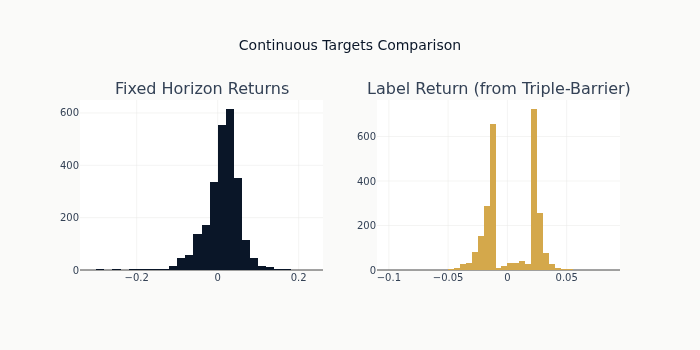

In [37]:
# Continuous targets comparison
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Fixed Horizon Returns", "Label Return (from Triple-Barrier)"],
    horizontal_spacing=0.1,
)

# Fixed horizon returns
fig.add_trace(
    go.Histogram(
        x=labels_returns[fh_label_col].drop_nulls().to_numpy(),
        nbinsx=50,
        name="Fixed Horizon",
        showlegend=False,
    ),
    row=1,
    col=1,
)

# Triple-barrier final returns (before discretization)
if "label_return" in labels_tb.columns:
    fig.add_trace(
        go.Histogram(
            x=labels_tb["label_return"].drop_nulls().to_numpy(),
            nbinsx=50,
            name="TB Label Return",
            showlegend=False,
        ),
        row=1,
        col=2,
    )

fig.update_layout(
    height=350,
    title_text="Continuous Targets Comparison",
)
fig.show()

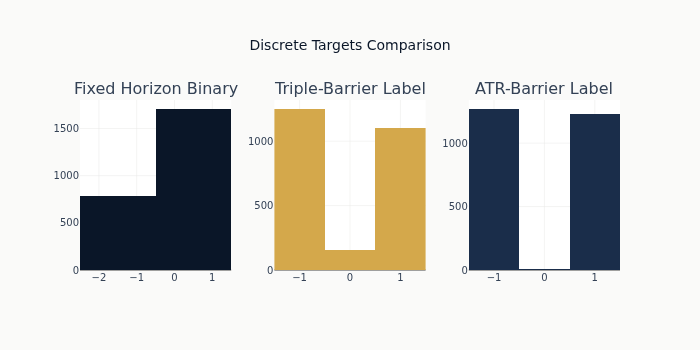

In [38]:
# Discrete targets comparison
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=["Fixed Horizon Binary", "Triple-Barrier Label", "ATR-Barrier Label"],
    horizontal_spacing=0.08,
)

# Fixed horizon binary
fig.add_trace(
    go.Histogram(
        x=labels_binary[binary_label_col].drop_nulls().to_numpy(),
        name="Binary",
        showlegend=False,
    ),
    row=1,
    col=1,
)

# Triple barrier discrete
fig.add_trace(
    go.Histogram(
        x=labels_tb.filter(pl.col("label").is_not_null())["label"].to_numpy(),
        name="Triple Barrier",
        showlegend=False,
    ),
    row=1,
    col=2,
)

# ATR barrier discrete
fig.add_trace(
    go.Histogram(
        x=labels_atr.filter(pl.col("label").is_not_null())["label"].to_numpy(),
        name="ATR Barrier",
        showlegend=False,
    ),
    row=1,
    col=3,
)

fig.update_layout(
    height=350,
    title_text="Discrete Targets Comparison",
)
fig.show()

## 10. Method Comparison: Decision Guide

| Strategy Type | Recommended Method | Rationale |
|--------------|-------------------|-----------|
| Factor timing (monthly) | Fixed horizon | Simple, stationary targets |
| Stat arb (intraday) | Fixed horizon binary | Speed matters |
| Cross-sectional ranking | **Cross-sectional percentile** | Stable class balance |
| Active trading | Triple barrier (ATR) | Matches trade mechanics |
| Trend following | Trend scanning | Data-driven trend ID |

**Key Considerations**:

1. **Anchor alignment**: Match label computation to execution timing
2. **Cross-sectional vs time-series**: Most equity/ETF strategies need cross-sectional
3. **Path-dependence**: Use triple-barrier when stop losses are part of the strategy
4. **Volatility adaptation**: ATR-based barriers for changing market conditions

## Summary

### Key Takeaways

1. **Fixed horizon** for simple regression/classification targets
2. **Rolling percentile** for time-series adaptive thresholds (single instrument)
3. **Cross-sectional percentile** for relative ranking within a universe
4. **Triple barrier (ATR)** for realistic trading simulations with stops
5. **Trend scanning** for data-driven trend identification
6. **Anchor alignment** is critical - close-to-close vs next-open matters

### Production Usage

For production label computation, use the experiment configuration module
which centralizes method, horizon, and threshold choices per case study.
The case study label notebooks (NB09–NB17) demonstrate this pipeline.

### References

- Lopez de Prado, M. (2018). *Advances in Financial Machine Learning*. Wiley.
  - Chapter 3: Labeling (Triple-Barrier, Meta-Labeling)
  - Chapter 4: Sample Weights (Uniqueness)
- See [`04_minimum_favorable_adverse_excursion`](04_minimum_favorable_adverse_excursion.ipynb) for empirical barrier calibration